# PHCpack Benchmark Analysis — split files (1–76 + 77–112)

Compares `degree`, `sugar`, and `s_poly_entropy` on the **PHCpack** dataset.

Each strategy has two result files (one per system-id range) which are concatenated here.

Sections:
1. Load and merge file pairs
2. Top-level summary
3. Timeouts and unique solves
4. Head-to-head winners on commonly-solved systems
5. Total runtime on commonly-solved systems
6. Entropy vs baselines (ratios)
7. Basis-size sanity check
8. Scatter: entropy vs sugar/degree
9. Distributions
10. **Where does entropy shine?** — systems and structural features where s‑poly entropy beats the baselines
11. Save summary CSVs

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_style('whitegrid')
pd.set_option('display.float_format', '{:.3f}'.format)

STRATEGY_ORDER  = ['degree', 'normal', 'sugar', 's_poly_entropy']
STRATEGY_COLORS = {
    'degree':         '#4C72B0',
    'normal':         '#8172B2',
    'sugar':          '#DD8452',
    's_poly_entropy': '#55A868',
}

def fmt_hms(s):
    if pd.isna(s): return '-'
    m = int(s // 60); sec = s - 60*m
    if m >= 60:
        h = m // 60; m = m % 60
        return f'{h}h {m:02d}m {sec:04.1f}s'
    if m > 0:
        return f'{m}m {sec:04.1f}s'
    return f'{sec:.2f}s'

def fmt_time_short(s):
    if pd.isna(s): return '-'
    if s < 1:  return f'{s*1000:.0f} ms'
    if s < 60: return f'{s:.2f} s'
    m = int(s // 60); sec = s - 60*m
    return f'{m}m {sec:04.1f}s'

def fmt_int(x):
    return '-' if pd.isna(x) else f'{int(round(x))}'


## 1. Load and merge the two file halves per strategy

Each strategy has a result file for systems 1–76 and another for 77–112. They share the same schema and are concatenated.

In [ ]:
RESULTS_DIR = Path('Path to results')

# Edit filenames as needed.
FILES = {
    'degree': [
        '2_PHC_Q_degree.csv',
    ],
    'normal': [
        '2_PHC_Q_normal.csv',
    ],
    'sugar': [
        '2_PHC_Q_sugar.csv',
    ],
    's_poly_entropy': [
        '2_PHC_Q_entropy.csv',
    ],
}
 

frames = []
for strat, fnames in FILES.items():
    parts = []
    for fn in fnames:
        path = RESULTS_DIR / fn
        if not path.exists():
            print(f'  MISSING: {strat} -> {path}')
            continue
        d = pd.read_csv(path)
        d['source_half'] = fn
        parts.append(d)
        print(f'  loaded {strat:18s}  {fn:60s}  {len(d):4d} rows  '
              f'sid {int(d.system_id.min())}-{int(d.system_id.max())}  '
              f'{int(d.finished.sum())} finished')
    if parts:
        merged = pd.concat(parts, ignore_index=True)
        merged['strategy'] = strat
        merged['finished'] = merged['finished'].astype(int)
        # Sanity: no duplicate system_ids per strategy after merge
        dups = merged[merged.duplicated('system_id', keep=False)]
        if len(dups):
            print(f'  WARNING: {strat} has {len(dups)} duplicate system_id rows after concat')
        frames.append(merged)

df = pd.concat(frames, ignore_index=True)
print(f'\nTotal rows: {len(df)}   unique systems: {df.system_id.nunique()}')
print(f'Strategies present: {sorted(df.strategy.unique())}')
print(f'Per-strategy coverage: {df.groupby("strategy").system_id.nunique().to_dict()}')


  loaded degree              2_PHC_Q_degree.csv                                              94 rows  sid 1-112  60 finished
  loaded normal              2_PHC_Q_normal.csv                                              94 rows  sid 1-112  57 finished
  loaded sugar               2_PHC_Q_sugar.csv                                               94 rows  sid 1-112  61 finished
  loaded s_poly_entropy      2_PHC_Q_entropy.csv                                             94 rows  sid 1-112  56 finished

Total rows: 376   unique systems: 94
Strategies present: ['degree', 'normal', 's_poly_entropy', 'sugar']
Per-strategy coverage: {'degree': 94, 'normal': 94, 's_poly_entropy': 94, 'sugar': 94}


## 1b. Filter to pure-real systems

Some PHC systems use the literal symbol `i` to denote the imaginary unit √-1 (e.g. system 31 has terms like `0.40458818397*i*a1`). When fed into a finite-field Buchberger pipeline, `i` is treated as just another free variable and the resulting computation is not the Gröbner basis of the original complex-coefficient system. This corrupts results on those systems — typically producing artificially small bases and unstable timings.

This section loads the PHC source polynomial CSVs, identifies systems whose polynomials contain `i` as a multiplicative factor, and **filters the benchmark dataframe `df` to keep only pure-real systems**. The rest of the notebook then runs on the cleaned subset.

Set `FILTER_COMPLEX = False` if you want to skip the filter.

## 2. Top-level summary (per strategy)

In [3]:
print(f"df has {df.system_id.nunique()} unique systems")
print(f"system IDs: {sorted(df.system_id.unique())}")
def fmt_hms(seconds):
    """Format seconds as 'Xh Ym Zs' (skip zero leading units)."""
    if pd.isna(seconds):
        return "—"
    s = int(round(seconds))
    h, rem = divmod(s, 3600)
    m, s = divmod(rem, 60)
    if h: return f"{h}h {m}m {s}s"
    if m: return f"{m}m {s}s"
    return f"{s}s"

# Restrict to systems where every strategy finished
strats_present = [s for s in STRATEGY_ORDER if s in df.strategy.unique()]
solved_per_strat = {
    s: set(df[(df.strategy == s) & (df.finished == 1)].system_id)
    for s in strats_present
}
common_ids = set.intersection(*solved_per_strat.values()) if solved_per_strat else set()
df_common = df[df.system_id.isin(common_ids)]

print(f"Strategies considered: {strats_present}")
print(f"Systems solved by ALL strategies: {len(common_ids)}")

# --- compute strict time wins on common systems ---
# A strategy "wins" a system if its elapsed time is strictly less than every
# other strategy's time on that same system.
wins_strict = {s: 0 for s in strats_present}
for sid in common_ids:
    times = {
        s: df_common[(df_common.strategy == s) &
                     (df_common.system_id == sid)].elapsed.iloc[0]
        for s in strats_present
    }
    best = min(times.values())
    winners = [s for s, t in times.items() if t == best]
    if len(winners) == 1:                # strict = unique winner
        wins_strict[winners[0]] += 1

rows = []
for strat in strats_present:
    sub_full   = df[df.strategy == strat]
    sub_common = df_common[df_common.strategy == strat]
    ok = sub_common[sub_common.finished == 1]

    total_with_timeouts    = sub_full.elapsed.sum()
    total_without_timeouts = sub_full[sub_full.finished == 1].elapsed.sum()
    total_common           = ok.elapsed.sum()

    rows.append({
        'strategy':                  strat,
        'n_total':                   len(sub_full),
        'n_finished':                int(sub_full.finished.sum()),
        'n_timeouts':                int((sub_full.finished == 0).sum()),
        'success_pct':               round(100 * sub_full.finished.mean(), 1),
        'strict_time_wins':          wins_strict[strat],
        'total_time_with_timeouts':    fmt_hms(total_with_timeouts),
        'total_time_without_timeouts': fmt_hms(total_without_timeouts),
        'total_time_common':           fmt_hms(total_common),
        'median_time':               ok.elapsed.median(),
        'mean_time':                 (ok.elapsed.mean()),
        'p90_time':                  (ok.elapsed.quantile(0.9)),
        'max_time':                  fmt_hms(ok.elapsed.max()),
        'median_steps':              ok.n_steps.median(),
        'mean_steps':                ok.n_steps.mean(),
        'p90_steps':                 ok.n_steps.quantile(0.9),
        'max_steps':                 ok.n_steps.max(),
        'median_basis':              ok.basis_size.median(),
    })
top_common = pd.DataFrame(rows)
print(f"\nTotal common systems: {len(common_ids)}")
print(f"Sum of strict wins across strategies: {sum(wins_strict.values())} "
      f"(remainder {len(common_ids) - sum(wins_strict.values())} are exact ties)")
top_common

df has 94 unique systems
system IDs: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 26, 29, 35, 36, 37, 38, 40, 41, 42, 43, 44, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 109, 110, 111, 112]
Strategies considered: ['degree', 'normal', 'sugar', 's_poly_entropy']
Systems solved by ALL strategies: 55

Total common systems: 55
Sum of strict wins across strategies: 55 (remainder 0 are exact ties)


,strategy,n_total,n_finished,n_timeouts,success_pct,strict_time_wins,total_time_with_timeouts,total_time_without_timeouts,total_time_common,median_time,mean_time,p90_time,max_time,median_steps,mean_steps,p90_steps,max_steps,median_basis
0,degree,94,60,34,63.800,25,6h 8m 30s,28m 30s,8m 4s,0.131,8.792,21.561,2m 49s,71.000,105.382,244.400,584,17.000
1,normal,94,57,37,60.600,14,6h 26m 15s,16m 14s,14m 3s,0.155,15.321,16.507,9m 39s,71.000,101.745,254.400,397,17.000
2,sugar,94,61,33,64.900,10,5h 42m 21s,12m 21s,3m 47s,0.121,4.134,15.106,56s,67.000,102.418,254.400,367,17.000
3,s_poly_entropy,94,56,38,59.600,6,6h 31m 19s,11m 19s,10m 59s,0.150,11.977,20.736,4m 7s,74.000,108.745,281.400,433,17.000


## 3. Timeouts: which systems timed out, and for whom?

In [4]:
strategies_present = [s for s in STRATEGY_ORDER if s in df.strategy.unique()]

timeouts_per_strat = df[df.finished == 0].groupby('strategy').size().reindex(
    strategies_present, fill_value=0)
print('Timeouts per strategy:')
print(timeouts_per_strat.to_string())

pivot_finished = df.pivot_table(
    index='system_id', columns='strategy',
    values='finished', aggfunc='first'
).reindex(columns=strategies_present)

timed_out_at_least_once = pivot_finished[(pivot_finished == 0).any(axis=1)]
print(f'\n{len(timed_out_at_least_once)} systems timed out under at least one strategy.')
print('\nFirst 30:')
print(timed_out_at_least_once.head(30).astype('Int64'))

Timeouts per strategy:
strategy
degree            34
normal            37
sugar             33
s_poly_entropy    38

39 systems timed out under at least one strategy.

First 30:
strategy   degree  normal  sugar  s_poly_entropy
system_id                                       
6               1       0      1               1
9               0       0      0               0
14              1       1      1               0
15              0       0      0               0
16              0       0      0               0
17              1       0      0               0
20              0       0      0               0
26              0       0      0               0
29              0       0      0               0
37              0       0      0               0
38              0       0      0               0
42              0       0      0               0
55              0       0      0               0
56              1       0      0               0
58              0       0      1      

In [5]:
# Systems uniquely solved by one strategy (others timed out)
print('Systems ONLY ONE strategy could solve:')
for s in strategies_present:
    others = [x for x in strategies_present if x != s]
    mask = (pivot_finished[s] == 1)
    for o in others:
        mask &= (pivot_finished[o] == 0)
    unique_ids = pivot_finished[mask].index.tolist()
    print(f'  {s:18s}  n = {len(unique_ids)}   ids = {unique_ids[:15]}'
          f'{"..." if len(unique_ids)>15 else ""}')

Systems ONLY ONE strategy could solve:
  degree              n = 2   ids = [17, 56]
  normal              n = 0   ids = []
  sugar               n = 2   ids = [58, 85]
  s_poly_entropy      n = 0   ids = []


## 4. Head-to-head winners on commonly-solved systems

In [6]:
ok_pivot = df[df.finished == 1].pivot_table(
    index='system_id', columns='strategy',
    values='finished', aggfunc='first')
common = ok_pivot.dropna(axis=0, how='any').index
print(f'Systems finished by all strategies: {len(common)}')

sub = df[df.system_id.isin(common)]
steps_piv   = sub.pivot(index='system_id', columns='strategy', values='n_steps')
elapsed_piv = sub.pivot(index='system_id', columns='strategy', values='elapsed')
basis_piv   = sub.pivot(index='system_id', columns='strategy', values='basis_size')

def classify_winner(row):
    m = row.min()
    winners = [s for s, v in zip(row.index, row.values) if v == m]
    return winners[0] if len(winners) == 1 else 'tie'

print('\nStrict winners by time elapsed:')
print(elapsed_piv.apply(classify_winner, axis=1).value_counts())

Systems finished by all strategies: 55

Strict winners by time elapsed:
degree            25
normal            14
sugar             10
s_poly_entropy     6
dtype: int64


## 5. Total runtime on commonly-solved systems

In [7]:
rows = []
for strat in strategies_present:
    all_sub = df[df.strategy == strat]
    own_total = all_sub[all_sub.finished == 1].elapsed.sum()
    common_total = all_sub[all_sub.system_id.isin(common)].elapsed.sum()
    rows.append({
        'strategy':        strat,
        'own_solved':      int(all_sub.finished.sum()),
        'common':          len(common),
        'own_total_s':     round(own_total, 2),
        'common_total_s':  round(common_total, 2),
        'own_total':       fmt_hms(own_total),
        'common_total':    fmt_hms(common_total),
    })
common_tbl = pd.DataFrame(rows)
winner_idx = common_tbl['common_total_s'].idxmin()
common_tbl['best_common'] = ''
common_tbl.at[winner_idx, 'best_common'] = '★'
print(common_tbl[['strategy','own_solved','common','own_total','common_total','best_common']].to_string(index=False))

      strategy  own_solved  common own_total common_total best_common
        degree          60      55   28m 30s        8m 4s            
        normal          57      55   16m 14s       14m 3s            
         sugar          61      55   12m 21s       3m 47s           ★
s_poly_entropy          56      55   11m 19s      10m 59s            


In [8]:
if 's_poly_entropy' in steps_piv.columns:
    for metric_name, piv in [('n_steps', steps_piv), ('elapsed', elapsed_piv)]:
        print(f'\n--- {metric_name} ratio (entropy / baseline) ---')
        for baseline in ['sugar', 'degree', 'normal']:
            if baseline not in piv.columns: continue
            r = (piv['s_poly_entropy'] / piv[baseline]).replace(
                [np.inf, -np.inf], np.nan).dropna()
            print(f'  vs {baseline}:  median={r.median():.3f}  '
                  f'mean={r.mean():.3f}  '
                  f'frac_entropy_wins={(r < 1).mean():.3f}  (n={len(r)})')



--- n_steps ratio (entropy / baseline) ---
  vs sugar:  median=1.031  mean=1.060  frac_entropy_wins=0.154  (n=52)
  vs degree:  median=1.000  mean=1.047  frac_entropy_wins=0.308  (n=52)
  vs normal:  median=1.005  mean=1.050  frac_entropy_wins=0.250  (n=52)

--- elapsed ratio (entropy / baseline) ---
  vs sugar:  median=1.188  mean=1.613  frac_entropy_wins=0.273  (n=55)
  vs degree:  median=1.172  mean=2.273  frac_entropy_wins=0.255  (n=55)
  vs normal:  median=1.152  mean=1.386  frac_entropy_wins=0.436  (n=55)


## 6. Scatter: entropy vs sugar / degree (log-log)

Points below the diagonal are systems where entropy beats the baseline.

Systems plotted (commonly solved): 55


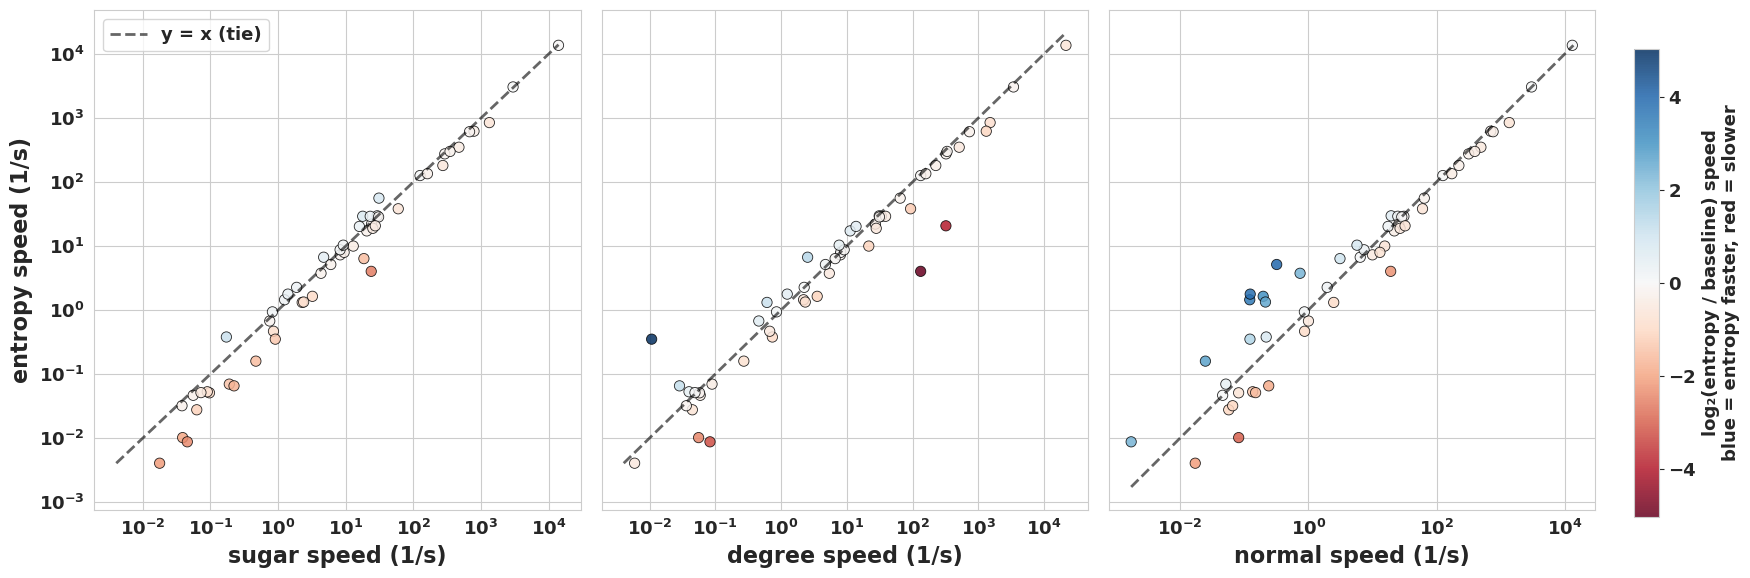

In [9]:
import matplotlib.pyplot as plt

if 's_poly_entropy' in df.strategy.unique():
    # --- restrict to systems all relevant strategies finished ---
    needed = {'s_poly_entropy', 'sugar', 'degree', 'normal'} & set(df.strategy.unique())
    solved_per_strat = {
        s: set(df[(df.strategy == s) & (df.finished == 1)].system_id)
        for s in needed
    }
    common_ids = set.intersection(*solved_per_strat.values())

    elapsed_common = elapsed_piv.loc[
        [sid for sid in elapsed_piv.index if sid in common_ids]
    ]
    print(f"Systems plotted (commonly solved): {len(elapsed_common)}")

    baselines = [b for b in ['sugar', 'degree', 'normal'] if b in elapsed_common.columns]
    n_base = len(baselines)

    # --- Bold + larger text settings, scoped to this figure only ---
    plt.rcParams.update({
        'font.size':         14,
        'font.weight':       'bold',
        'axes.labelsize':    16,
        'axes.labelweight':  'bold',
        'axes.titlesize':    15,
        'axes.titleweight':  'bold',
        'xtick.labelsize':   13,
        'ytick.labelsize':   13,
        'legend.fontsize':   13,
    })

    # Shared colour scale across panels
    eps = 1e-6
    all_log_speedups = []
    for baseline in baselines:
        xs_speed = 1.0 / (elapsed_common[baseline].values + eps)
        ys_speed = 1.0 / (elapsed_common['s_poly_entropy'].values + eps)
        all_log_speedups.append(np.log2(ys_speed / xs_speed))
    all_log_speedups = np.concatenate(all_log_speedups)
    vmax = max(abs(np.nanmin(all_log_speedups)), abs(np.nanmax(all_log_speedups)))

    fig, axes = plt.subplots(
        1, n_base,
        figsize=(5.5 * n_base + 1, 6),
        squeeze=False,
        sharey=True,
    )
    axes = axes[0]

    sc = None
    for col_idx, baseline in enumerate(baselines):
        ax = axes[col_idx]
        xs_speed = 1.0 / (elapsed_common[baseline].values + eps)
        ys_speed = 1.0 / (elapsed_common['s_poly_entropy'].values + eps)
        log2_speedup = np.log2(ys_speed / xs_speed)

        sc = ax.scatter(xs_speed, ys_speed, c=log2_speedup, cmap='RdBu',
                        vmin=-vmax, vmax=vmax,
                        s=55, alpha=0.85, edgecolor='black', linewidth=0.6)

        lo = max(1e-3, np.nanmin(np.concatenate([xs_speed, ys_speed])))
        hi = np.nanmax(np.concatenate([xs_speed, ys_speed]))
        ax.plot([lo, hi], [lo, hi], 'k--', linewidth=2, alpha=0.6,
                label='y = x (tie)' if col_idx == 0 else None)

        ax.set_xscale('log'); ax.set_yscale('log')
        ax.set_xlabel(f'{baseline} speed (1/s)', fontweight='bold')
        # ax.set_title(f'entropy vs {baseline}  —  speed\n'
        #              f'above diagonal = entropy wins  '
        #              f'(n = {len(elapsed_common)})',
        #              fontweight='bold')

        # Make tick labels bold too (matplotlib doesn't pick this up from rcParams)
        for label in ax.get_xticklabels() + ax.get_yticklabels():
            label.set_fontweight('bold')

        if col_idx == 0:
            ax.set_ylabel('entropy speed (1/s)', fontweight='bold')
            leg = ax.legend(loc='upper left')
            for text in leg.get_texts():
                text.set_fontweight('bold')

    fig.tight_layout(rect=[0, 0, 0.93, 1])
    cbar_ax = fig.add_axes([0.94, 0.12, 0.014, 0.78])
    cbar = fig.colorbar(sc, cax=cbar_ax)
    cbar.set_label('log\u2082(entropy / baseline) speed\n'
                   'blue = entropy faster, red = slower',
                   fontsize=13, fontweight='bold')
    # Bold the colour-bar tick labels too
    for label in cbar.ax.get_yticklabels():
        label.set_fontweight('bold')

    plt.show()

## 7. Distribution of elapsed time per strategy

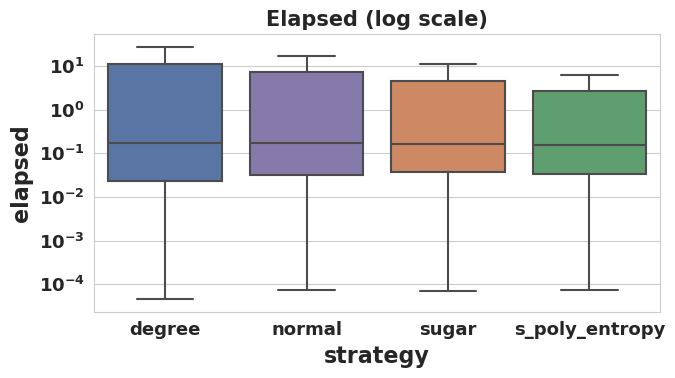

In [10]:
ok = df[df.finished == 1]
if not ok.empty:
    fig, ax = plt.subplots(figsize=(7, 4))
    sns.boxplot(data=ok, x='strategy', y='elapsed',
                order=[s for s in STRATEGY_ORDER if s in ok.strategy.unique()],
                palette=STRATEGY_COLORS, showfliers=False, ax=ax)
    ax.set_yscale('log')
    ax.set_title('Elapsed (log scale)')
    plt.tight_layout()
    plt.show()

## 8. Where does s‑poly entropy perform better?

For each commonly-solved system, compute the speedup `baseline_time / entropy_time` (also for n_steps). Rank, then look at the top vs bottom — and pull in structural features (nvars, neqs, basis_size) to characterise where entropy wins.

If you have the raw polynomial CSV available, set `POLY_CSV` below to also extract degree/term-count features per system.

In [11]:
# Build a per-system table on the commonly-solved set
baselines = [b for b in ['sugar', 'degree', 'normal'] if b in elapsed_piv.columns]

speedup_dict = {
    'elapsed_entropy': elapsed_piv['s_poly_entropy'],
    'steps_entropy':   steps_piv['s_poly_entropy'],
    'basis_size':      basis_piv['s_poly_entropy'],
}
for b in baselines:
    speedup_dict[f'elapsed_{b}'] = elapsed_piv[b]
    speedup_dict[f'steps_{b}']   = steps_piv[b]
speedups = pd.DataFrame(speedup_dict).dropna(subset=['elapsed_entropy'])

# Per-baseline speedups (time and steps)
for b in baselines:
    speedups[f'speedup_t_vs_{b}']     = speedups[f'elapsed_{b}'] / speedups['elapsed_entropy']
    speedups[f'steps_ratio_vs_{b}']   = speedups['steps_entropy'] / speedups[f'steps_{b}']

# Best-baseline aggregates
elapsed_cols = [f'elapsed_{b}' for b in baselines]
steps_cols   = [f'steps_{b}'   for b in baselines]
speedups['baseline_best_t']      = speedups[elapsed_cols].min(axis=1)
speedups['speedup_t_vs_best']    = speedups['baseline_best_t'] / speedups['elapsed_entropy']
speedups['baseline_best_steps']  = speedups[steps_cols].min(axis=1)
speedups['steps_ratio_vs_best']  = speedups['steps_entropy'] / speedups['baseline_best_steps']

# Attach nvars/neqs from the original df
meta = df[['system_id','nvars','neqs','domain']].drop_duplicates('system_id').set_index('system_id')
speedups = speedups.join(meta, how='left')

speedups.head()


,elapsed_entropy,steps_entropy,basis_size,elapsed_sugar,steps_sugar,elapsed_degree,steps_degree,elapsed_normal,steps_normal,speedup_t_vs_sugar,...,steps_ratio_vs_degree,speedup_t_vs_normal,steps_ratio_vs_normal,baseline_best_t,speedup_t_vs_best,baseline_best_steps,steps_ratio_vs_best,nvars,neqs,domain
system_id,,,,,,,,,,,,,,,,,,,,,
1,0.018,94,12,0.032,130,0.015,112,0.016,115,1.811,...,0.839,0.868,0.817,0.015,0.865,112,0.839,6,6,Q
2,0.691,205,22,0.803,226,0.454,210,8.190,211,1.163,...,0.976,11.854,0.972,0.454,0.658,210,0.976,7,7,Q
3,2.637,299,29,5.820,342,1.356,218,4.535,264,2.207,...,1.372,1.720,1.133,1.356,0.514,218,1.372,8,8,Q
4,14.362,129,26,5.270,112,11.218,122,19.325,118,0.367,...,1.057,1.346,1.093,5.270,0.367,112,1.152,6,6,Q
5,0.034,94,31,0.034,88,0.032,88,0.051,112,1.015,...,1.068,1.512,0.839,0.032,0.953,88,1.068,4,4,Q


In [12]:
baselines = [b for b in ['sugar', 'degree', 'normal'] if f'elapsed_{b}' in speedups.columns]
elapsed_cols = ['elapsed_entropy'] + [f'elapsed_{b}' for b in baselines]
steps_cols   = ['steps_entropy']   + [f'steps_{b}'   for b in baselines]
cols_show = ['nvars','neqs','basis_size'] + elapsed_cols + ['speedup_t_vs_best'] + steps_cols

print('='*80)
print('TOP 15 systems where ENTROPY most outperforms the BEST baseline (by elapsed time)')
print('='*80)
top_t = speedups.sort_values('speedup_t_vs_best', ascending=False).head(15)
print(top_t[cols_show].round(3).to_string())

print('\n' + '='*80)
print('TOP 15 systems where ENTROPY uses fewest steps relative to the best baseline')
print('='*80)
top_s = speedups.sort_values('steps_ratio_vs_best', ascending=True).head(15)
print(top_s[cols_show + ['steps_ratio_vs_best']].round(3).to_string())

print('\n' + '='*80)
print('BOTTOM 15: systems where entropy is WORST relative to baselines (time)')
print('='*80)
bot_t = speedups.sort_values('speedup_t_vs_best', ascending=True).head(15)
print(bot_t[cols_show].round(3).to_string())


TOP 15 systems where ENTROPY most outperforms the BEST baseline (by elapsed time)
           nvars  neqs  basis_size  elapsed_entropy  elapsed_sugar  elapsed_degree  elapsed_normal  speedup_t_vs_best  steps_entropy  steps_sugar  steps_degree  steps_normal
system_id                                                                                                                                                                    
8              4     4          25            0.564          0.716           0.806           8.060              1.270             92           91           103           102
83             4     4          10            0.049          0.063           0.072           0.057              1.152             32           31            39            29
57             7     6          11            0.097          0.109           0.131           0.174              1.122             99           91            86            84
49             5     5          72            1.

In [13]:
# # Bucket systems by entropy outcome and summarise structural averages
# def bucket(r):
#     if r >= 2.0:  return 'big_win   (\u22652x)'
#     if r >= 1.1:  return 'win       (1.1\u20132x)'
#     if r >= 0.9:  return 'tie       (0.9\u20131.1x)'
#     if r >= 0.5:  return 'lose      (0.5\u20130.9x)'
#     return 'big_lose  (<0.5x)'

# speedups['bucket'] = speedups['speedup_t_vs_best'].map(bucket)

# agg_dict = {
#     'n_systems':       ('basis_size', 'size'),
#     'median_nvars':    ('nvars', 'median'),
#     'median_neqs':     ('neqs', 'median'),
#     # 'median_basis':    ('basis_size', 'median'),
#     # 'median_steps_e':  ('steps_entropy', 'median'),
# }
# # for b in ['sugar', 'degree', 'normal']:
# #     if f'steps_{b}' in speedups.columns:
# #         agg_dict[f'median_steps_{b[0]}'] = (f'steps_{b}', 'median')

# by_bucket = speedups.groupby('bucket').agg(**agg_dict).round(2)
# print('Per-bucket structural medians:')
# print(by_bucket.to_string())


In [14]:
def fmt_time(seconds):
    """Format seconds into ms / s / m / hours, paper-style."""
    if pd.isna(seconds):
        return "—"
    if seconds < 1:
        return f"{int(round(seconds * 1000))}\\,ms"
    if seconds < 60:
        return f"{seconds:.2f}\\,s"
    if seconds < 3600:
        m, s = divmod(seconds, 60)
        return f"{int(m)}m {s:.1f}s"
    h, rem = divmod(seconds, 3600)
    m, _ = divmod(rem, 60)
    return f"{int(h)}h {int(m)}m"


# --- 1. restrict to systems all four strategies finished ---
strats = ['sugar', 'degree', 'normal', 's_poly_entropy']
# only include strategies actually in df (in case 'normal' isn't loaded yet)
strats = [s for s in strats if s in df.strategy.unique()]

solved = {
    s: set(df[(df.strategy == s) & (df.finished == 1)].system_id)
    for s in strats
}
common_ids = set.intersection(*solved.values())
df_c = df[df.system_id.isin(common_ids) & df.strategy.isin(strats)]

# --- 2. bucket each system by sugar's wall time ---
sugar_t = (df_c[df_c.strategy == 'sugar']
           .set_index('system_id')['elapsed'])

def bucket(t):
    if t < 0.1:  return 'easy'
    if t < 10:   return 'medium'
    return 'hard'

bucket_of = {sid: bucket(sugar_t[sid]) for sid in common_ids}
buckets = ['easy', 'medium', 'hard']
sids_per_bucket = {b: [s for s, bk in bucket_of.items() if bk == b]
                   for b in buckets}

# --- 3. strict per-bucket time wins ---
wins = {b: {s: 0 for s in strats} for b in buckets}
for sid in common_ids:
    times = {
        s: df_c[(df_c.strategy == s) & (df_c.system_id == sid)].elapsed.iloc[0]
        for s in strats
    }
    best = min(times.values())
    winners = [s for s, t in times.items() if t == best]
    if len(winners) == 1:
        wins[bucket_of[sid]][winners[0]] += 1

# --- 4. per-bucket per-strategy stats ---
def stats_for(strategy, sids):
    sub = df_c[(df_c.strategy == strategy) & (df_c.system_id.isin(sids))]
    return sub.elapsed.mean(), sub.elapsed.median(), sub.elapsed.sum()

label_for = {
    'easy':   r"Easy ($<0.1$\,s, $n=%d$)",
    'medium': r"Medium ($0.1$--$10$\,s, $n=%d$)",
    'hard':   r"Hard ($>10$\,s, $n=%d$)",
}
display_name = {
    'sugar':          'Sugar',
    'degree':         'Degree',
    'normal':         'Normal',
    's_poly_entropy': 'Entropy',
}

# --- 5. emit LaTeX ---
lines = []
lines.append(r"\begin{table}[t]")
lines.append(r"\centering")
lines.append(r"\caption{PHCpack benchmark, stratified by difficulty using sugar's wall time. "
             r"Per-bucket best in \textbf{\textcolor{blue}{blue bold text}}. "
             r"Wins = strict time wins (unique fastest) within bucket.}")
lines.append(r"\label{tab:phcpack-stratified}")
lines.append(r"\begin{tabular}{l l c c c c}")
lines.append(r"\toprule")
lines.append(r"Difficulty bucket & Strategy  & Mean & Median & Total & Wins \\")
lines.append(r"\midrule")

for bi, b in enumerate(buckets):
    sids = sids_per_bucket[b]
    n = len(sids)
    if n == 0:
        continue

    bucket_stats = {s: stats_for(s, sids) for s in strats}
    best_mean   = min(bucket_stats[s][0] for s in strats)
    best_median = min(bucket_stats[s][1] for s in strats)
    best_total  = min(bucket_stats[s][2] for s in strats)
    best_wins   = max(wins[b][s] for s in strats)

    bucket_label = label_for[b] % n

    for si, s in enumerate(strats):
        mean_v, med_v, tot_v = bucket_stats[s]
        wn = wins[b][s]
        mean_str = fmt_time(mean_v)
        med_str  = fmt_time(med_v)
        tot_str  = fmt_time(tot_v)
        wn_str   = str(wn)

        if mean_v   == best_mean:   mean_str = r"{\color{blue}\textbf{%s}}" % mean_str
        if med_v    == best_median: med_str  = r"{\color{blue}\textbf{%s}}" % med_str
        if tot_v    == best_total:  tot_str  = r"{\color{blue}\textbf{%s}}" % tot_str
        if wn       == best_wins and wn > 0:
            wn_str = r"{\color{blue}\textbf{%s}}" % wn_str

        first_col = bucket_label if si == 0 else ""
        lines.append(f"{first_col} & {display_name[s]} & {mean_str} & {med_str} & {tot_str} & {wn_str} \\\\")

    if bi < len(buckets) - 1:
        lines.append(r"\midrule")

lines.append(r"\bottomrule")
lines.append(r"\end{tabular}")
lines.append(r"\end{table}")

latex = "\n".join(lines)
print(latex)

# sanity check
print("\n--- sanity check ---")
print(f"Strategies in table:     {strats}")
print(f"Common systems:          {len(common_ids)}")
for b in buckets:
    win_summary = "  ".join(f"{display_name[s].lower()}={wins[b][s]}" for s in strats)
    ties = len(sids_per_bucket[b]) - sum(wins[b].values())
    print(f"  {b:7s} (n={len(sids_per_bucket[b])}): {win_summary}  ties={ties}")

\begin{table}[t]
\centering
\caption{PHCpack benchmark, stratified by difficulty using sugar's wall time. Per-bucket best in \textbf{\textcolor{blue}{blue bold text}}. Wins = strict time wins (unique fastest) within bucket.}
\label{tab:phcpack-stratified}
\begin{tabular}{l l c c c c}
\toprule
Difficulty bucket & Strategy  & Mean & Median & Total & Wins \\
\midrule
Easy ($<0.1$\,s, $n=25$) & Sugar & 26\,ms & 32\,ms & 649\,ms & 2 \\
 & Degree & {\color{blue}\textbf{25\,ms}} & {\color{blue}\textbf{8\,ms}} & {\color{blue}\textbf{616\,ms}} & {\color{blue}\textbf{18}} \\
 & Normal & 35\,ms & 17\,ms & 866\,ms & 4 \\
 & Entropy & 39\,ms & 26\,ms & 977\,ms & 1 \\
\midrule
Medium ($0.1$--$10$\,s, $n=21$) & Sugar & {\color{blue}\textbf{1.28\,s}} & 533\,ms & {\color{blue}\textbf{26.82\,s}} & 5 \\
 & Degree & 7.35\,s & {\color{blue}\textbf{454\,ms}} & 2m 34.4s & 5 \\
 & Normal & 5.32\,s & 1.34\,s & 1m 51.7s & {\color{blue}\textbf{6}} \\
 & Entropy & 2.43\,s & 691\,ms & 51.02\,s & 5 \\
\midrule
Hard